# Recommender system: first steps

## Load data

In [87]:
%pip install -U --no-cache-dir scikit-surprise==1.1.5

In [ ]:
# Dataset.load_builtin downloads MovieLens on first use and manages
# the Surprise cache layout itself.

In [89]:
from surprise import Dataset

data = Dataset.load_builtin("ml-100k", prompt=False)

## Visualization

In [5]:
import pandas as pd

In [90]:
df = pd.DataFrame(data.raw_ratings, columns=["userId", "movieId", "rating", "timestamp"])
df

,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596
...,...,...,...,...
99995,880,476,3.0,880175444
99996,716,204,5.0,879795543
99997,276,1090,1.0,874795795
99998,13,225,2.0,882399156


In [91]:
df.apply("nunique")

,0
userId,943
movieId,1682
rating,5
timestamp,49282


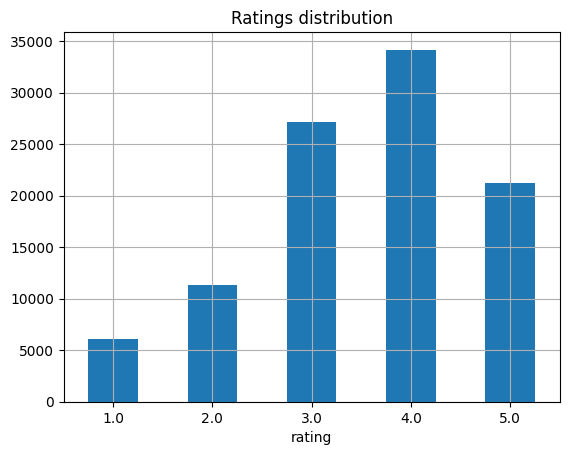

In [92]:
df["rating"].value_counts().sort_index().plot.bar(title="Ratings distribution", rot=0).grid();

## Train and test split

In [93]:
from surprise.model_selection import train_test_split

In [94]:
trainset, testset = train_test_split(
    data,
    test_size=0.25,
    random_state=42,
)

In [95]:
from surprise import Reader

# Rebuild a Surprise dataset using training ratings only
train_ratings_df = pd.DataFrame(
    [
        (
            trainset.to_raw_uid(uid),
            trainset.to_raw_iid(iid),
            rating,
        )
        for uid, iid, rating in trainset.all_ratings()
    ],
    columns=["userId", "movieId", "rating"],
)

tuning_data = Dataset.load_from_df(
    train_ratings_df[["userId", "movieId", "rating"]],
    Reader(rating_scale=(1, 5)),
)

# EDA


In [96]:
import matplotlib.pyplot as plt

In [97]:
df_train = pd.DataFrame(
    data=[i for i in trainset.all_ratings()],
    columns=["user", "movie", "rating"],
)

df_train.shape

(75000, 3)

In [98]:
users_train = df_train.groupby("user")["rating"].count()

print("Mean:   ", users_train.mean())
print("Std:    ", users_train.std())
print("Median: ", users_train.median())

Mean:    79.53340402969248
Std:     75.83102722356018
Median:  48.0


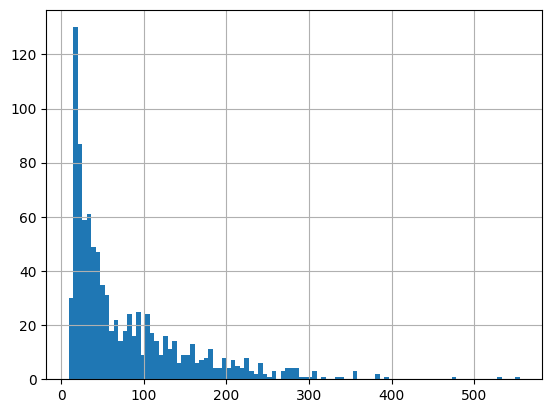

In [99]:
users_train.hist(bins=100);

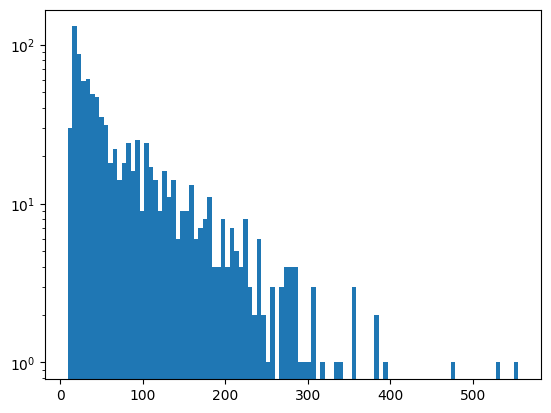

In [100]:
plt.hist(users_train, bins=100, log=True);

In [101]:
movies_train = df_train.groupby("movie")["rating"].count()

print("Mean:   ", movies_train.mean())
print("Std:    ", movies_train.std())
print("Median: ", movies_train.median())

Mean:    45.62043795620438
Std:     60.70712924070807
Median:  21.0


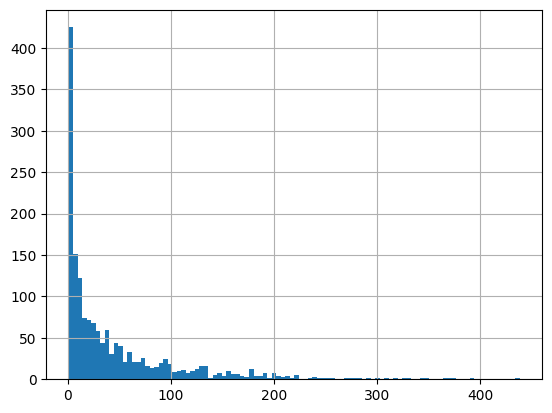

In [102]:
movies_train.hist(bins=100);

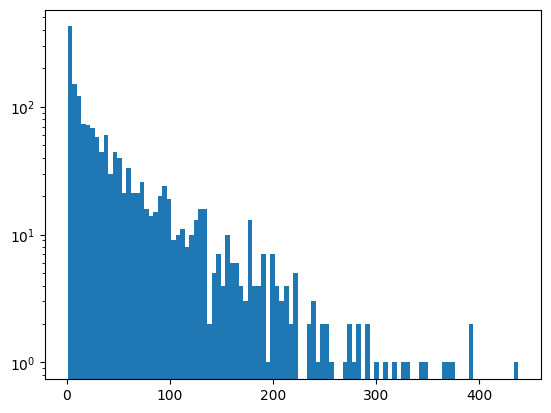

In [103]:
plt.hist(movies_train, bins=100, log=True);

## [Last.fm](https://en.wikipedia.org/wiki/Last.fm) dataset



In [65]:
# !pip install implicit

In [23]:
!curl -kL "https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip" \
  -o lastfm.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2528k  100 2528k    0     0  1751k      0  0:00:01  0:00:01 --:--:-- 1750k


In [104]:
from pathlib import Path
import zipfile
import pandas as pd

output_dir = Path("lastfm_data")

with zipfile.ZipFile("lastfm.zip", "r") as archive:
    archive.extractall(output_dir)

data_dir = next(path.parent for path in output_dir.rglob("user_artists.dat"))

user_artists = pd.read_csv(data_dir / "user_artists.dat", sep="\t")
tags = pd.read_csv(data_dir / "tags.dat", sep="\t", encoding="latin-1")
artists = pd.read_csv(data_dir / "artists.dat", sep="\t", encoding="latin-1")
user_taggedartists = pd.read_csv(data_dir / "user_taggedartists.dat", sep="\t")

display(user_artists.head())
display(artists.head())
display(user_taggedartists.head())

,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


,id,name,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


,userID,artistID,tagID,day,month,year
0,2,52,13,1,4,2009
1,2,52,15,1,4,2009
2,2,52,18,1,4,2009
3,2,52,21,1,4,2009
4,2,52,41,1,4,2009


In [106]:
user_artists.shape

(92834, 3)

In [107]:
# Use a consistent artist ID column name
artists = artists.rename(columns={"id": "artistID"})

print("Listening interactions:", user_artists.shape)
print("Tagging events:", user_taggedartists.shape)
print("Artists:", artists.shape)
print("Tags:", tags.shape)

Listening interactions: (92834, 3)
Tagging events: (186479, 6)
Artists: (17632, 4)
Tags: (11946, 2)


In [108]:
# Size and sparsity of the user-item matrix
n_users = user_artists["userID"].nunique()
n_artists = user_artists["artistID"].nunique()
n_interactions = len(user_artists)

density = n_interactions / (n_users * n_artists)

print(f"Users: {n_users:,}")
print(f"Artists: {n_artists:,}")
print(f"User-artist interactions: {n_interactions:,}")
print(f"Matrix density: {density:.3%}")

Users: 1,892
Artists: 17,632
User-artist interactions: 92,834
Matrix density: 0.278%


In [109]:
# Number of distinct artists per user
artists_per_user = user_artists.groupby("userID")["artistID"].nunique()

# Total listening count per user
plays_per_user = user_artists.groupby("userID")["weight"].sum()

# Tagging activity per user
tag_events_per_user = user_taggedartists.groupby("userID").size()
tagged_artists_per_user = (
    user_taggedartists.groupby("userID")["artistID"].nunique()
)

for name, series in {
    "Artists per user": artists_per_user,
    "Listening count per user": plays_per_user,
    "Tagging events per user": tag_events_per_user,
    "Distinct tagged artists per user": tagged_artists_per_user,
}.items():
    print(f"\n{name}")
    print("Mean:  ", round(series.mean(), 2))
    print("Median:", round(series.median(), 2))
    print("Max:   ", series.max())


Artists per user
Mean:   49.07
Median: 50.0
Max:    50

Listening count per user
Mean:   36566.58
Median: 21573.0
Max:    480039

Tagging events per user
Mean:   98.56
Median: 20.0
Max:    2609

Distinct tagged artists per user
Mean:   37.56
Median: 8.0
Max:    1208


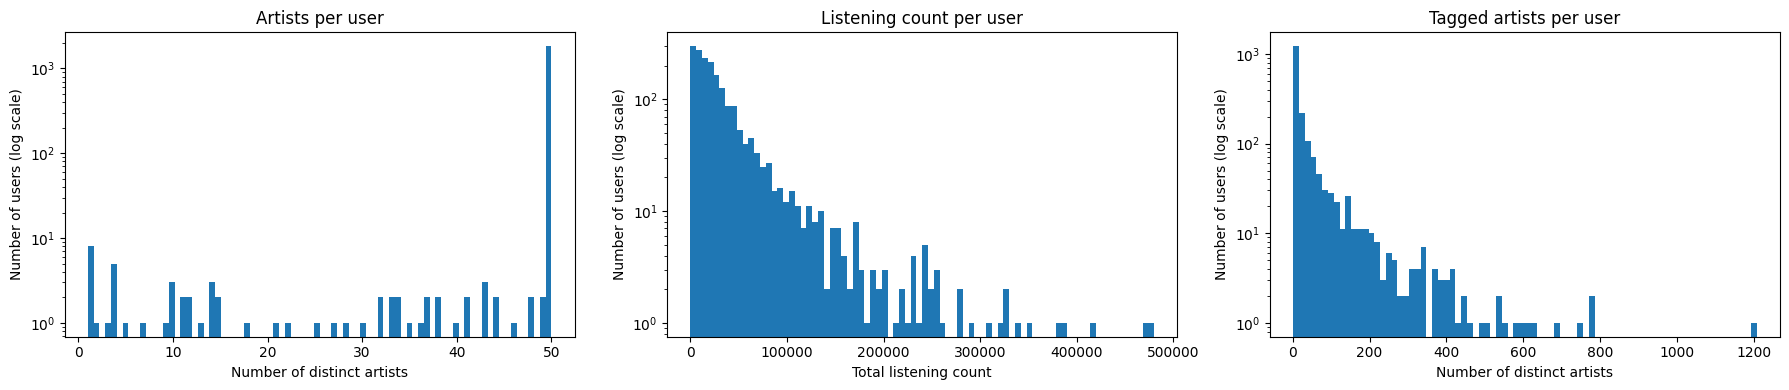

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(artists_per_user, bins=80, log=True)
axes[0].set_title("Artists per user")
axes[0].set_xlabel("Number of distinct artists")
axes[0].set_ylabel("Number of users (log scale)")

axes[1].hist(plays_per_user, bins=80, log=True)
axes[1].set_title("Listening count per user")
axes[1].set_xlabel("Total listening count")
axes[1].set_ylabel("Number of users (log scale)")

axes[2].hist(tagged_artists_per_user, bins=80, log=True)
axes[2].set_title("Tagged artists per user")
axes[2].set_xlabel("Number of distinct artists")
axes[2].set_ylabel("Number of users (log scale)")

plt.tight_layout()
plt.show()

,name,weight
0,Britney Spears,2393140
1,Depeche Mode,1301308
2,Lady Gaga,1291387
3,Christina Aguilera,1058405
4,Paramore,963449
5,Madonna,921198
6,Rihanna,905423
7,Shakira,688529
8,The Beatles,662116
9,Katy Perry,532545


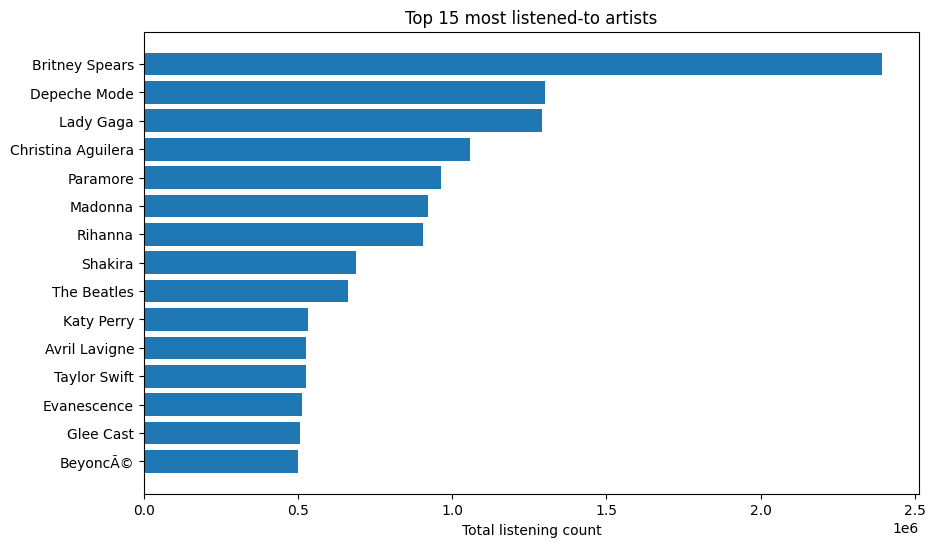

In [111]:
# Most listened-to artists
top_artists = (
    user_artists.groupby("artistID", as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=False)
    .head(15)
    .merge(artists[["artistID", "name"]], on="artistID", how="left")
)

display(top_artists[["name", "weight"]])

plt.figure(figsize=(10, 6))
plt.barh(top_artists["name"][::-1], top_artists["weight"][::-1])
plt.title("Top 15 most listened-to artists")
plt.xlabel("Total listening count")
plt.show()

,tagValue,tag_events
0,rock,7503
1,pop,5418
2,alternative,5251
3,electronic,4672
4,indie,4458
5,female vocalists,4228
6,80s,2791
7,dance,2739
8,alternative rock,2631
9,classic rock,2287


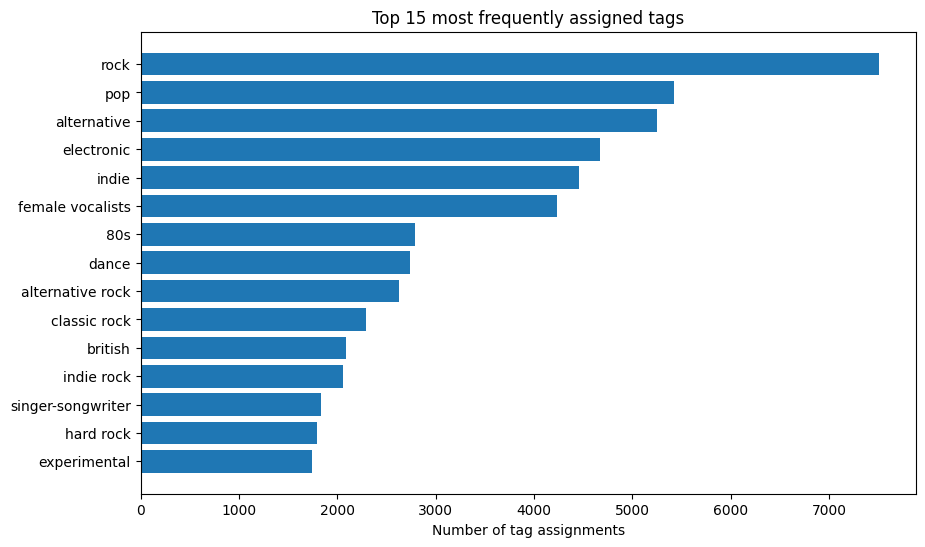

In [112]:
# Most frequently assigned tags
top_tags = (
    user_taggedartists.groupby("tagID")
    .size()
    .reset_index(name="tag_events")
    .sort_values("tag_events", ascending=False)
    .head(15)
    .merge(tags, on="tagID", how="left")
)

display(top_tags[["tagValue", "tag_events"]])

plt.figure(figsize=(10, 6))
plt.barh(top_tags["tagValue"][::-1], top_tags["tag_events"][::-1])
plt.title("Top 15 most frequently assigned tags")
plt.xlabel("Number of tag assignments")
plt.show()

# Models

The goal is to predict the rating that a user would assign to a movie.

Evaluation metrics:
- RMSE: penalizes larger prediction errors more strongly;
- MAE: average absolute prediction error.

In [114]:
def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    return rmse, mae

## Baselines

In [115]:
import numpy as np

# Overall average rating in the training data
global_mean = trainset.global_mean

# Average rating for each item and each user
item_means = {
    trainset.to_raw_iid(iid): np.mean([rating for _, rating in ratings])
    for iid, ratings in trainset.ir.items()
}

user_means = {
    trainset.to_raw_uid(uid): np.mean([rating for _, rating in ratings])
    for uid, ratings in trainset.ur.items()
}

# Ground-truth ratings from the test set
y_true = np.array([rating for _, _, rating in testset])

global_predictions = np.full(len(testset), global_mean)
item_predictions = np.array(
    [item_means.get(iid, global_mean) for _, iid, _ in testset]
)
user_predictions = np.array(
    [user_means.get(uid, global_mean) for uid, _, _ in testset]
)

baseline_results = []

for model_name, predictions_baseline in {
    "Global mean": global_predictions,
    "Item mean": item_predictions,
    "User mean": user_predictions,
}.items():
    rmse, mae = evaluate_predictions(y_true, predictions_baseline)
    baseline_results.append(
        {"Model": model_name, "RMSE": rmse, "MAE": mae}
    )

baseline_results = pd.DataFrame(baseline_results)
display(baseline_results.round(3))

,Model,RMSE,MAE
0,Global mean,1.130,0.948
1,Item mean,1.029,0.820
2,User mean,1.045,0.836


## Simple model


In [116]:
from surprise import SVD, KNNBasic, accuracy

In [117]:
algo = SVD()

In [118]:
algo.fit(trainset)

predictions = algo.test(testset)
svd_predictions = np.array([prediction.est for prediction in predictions])

svd_rmse, svd_mae = evaluate_predictions(y_true, svd_predictions)

svd_result = pd.DataFrame(
    [{"Model": "SVD", "RMSE": svd_rmse, "MAE": svd_mae}]
)

comparison = pd.concat([baseline_results, svd_result], ignore_index=True)
display(comparison.sort_values("RMSE").round(3))

,Model,RMSE,MAE
3,SVD,0.942,0.743
1,Item mean,1.029,0.820
2,User mean,1.045,0.836
0,Global mean,1.130,0.948


## Cross validation

In [119]:
from surprise.model_selection import GridSearchCV, cross_validate

In [ ]:
algo = SVD()

cross_validate(algo, tuning_data, measures=["RMSE", "MAE"], cv=5, verbose=True)

## Grid search

In [ ]:
from surprise.model_selection import GridSearchCV

In [ ]:
params = {
    "n_epochs": [10, 20, 30, 50],
    "lr_all": [0.001, 0.01, 0.05],
    "reg_all": [0.01, 0.05, 0.1],
}

svd_grid = GridSearchCV(
    SVD,
    param_grid=params,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1,
    return_train_measures=True,
)

svd_grid.fit(tuning_data)

svd_grid.best_score, svd_grid.best_params

In [ ]:
best_svd_params = svd_grid.best_params["rmse"]

final_svd = SVD(**best_svd_params, random_state=42)
final_svd.fit(trainset)

final_predictions = final_svd.test(testset)

accuracy.rmse(final_predictions)
accuracy.mae(final_predictions)

In [ ]:
knn_model = KNNBasic()
knn_model.fit(trainset)

In [ ]:
final_predictions = knn_model.test(testset)

accuracy.rmse(final_predictions)
accuracy.mae(final_predictions)

In [ ]:
# Get final predictions

algo = SVD(**best_svd_params, random_state=42)
algo.fit(trainset)

preds = algo.test(testset)

In [127]:
def get_top_n(predictions, n=3):
    """Return the top-N recommendation for each user from a set of predictions.

    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.

    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    """

    # First map the predictions to each user.
    top_n = {}
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid] = top_n.get(uid, []) + [(iid, est)]

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [128]:
top_n = get_top_n(preds, n=3)
len(top_n)

943

In [129]:
all_recommends = []
for user_ratings in top_n.values():
    movies = [iid for (iid, _) in user_ratings]
    all_recommends += movies

uniq_movies = set(all_recommends)
len(uniq_movies)

406

In [130]:
freq_rcmnd = pd.Series(all_recommends).value_counts()
freq_rcmnd.head(10)

,count
50,105
100,79
98,62
302,62
174,58
318,57
64,57
313,56
127,56
483,52


In [131]:
df[df["movieId"] == "50"]

,userId,movieId,rating,timestamp
499,290,50,5.0,880473582
857,79,50,4.0,891271545
1052,2,50,5.0,888552084
1090,8,50,5.0,879362124
1121,274,50,5.0,878944679
...,...,...,...,...
99567,749,50,5.0,878846978
99643,886,50,5.0,876031501
99853,739,50,4.0,886958895
99928,903,50,5.0,891031329


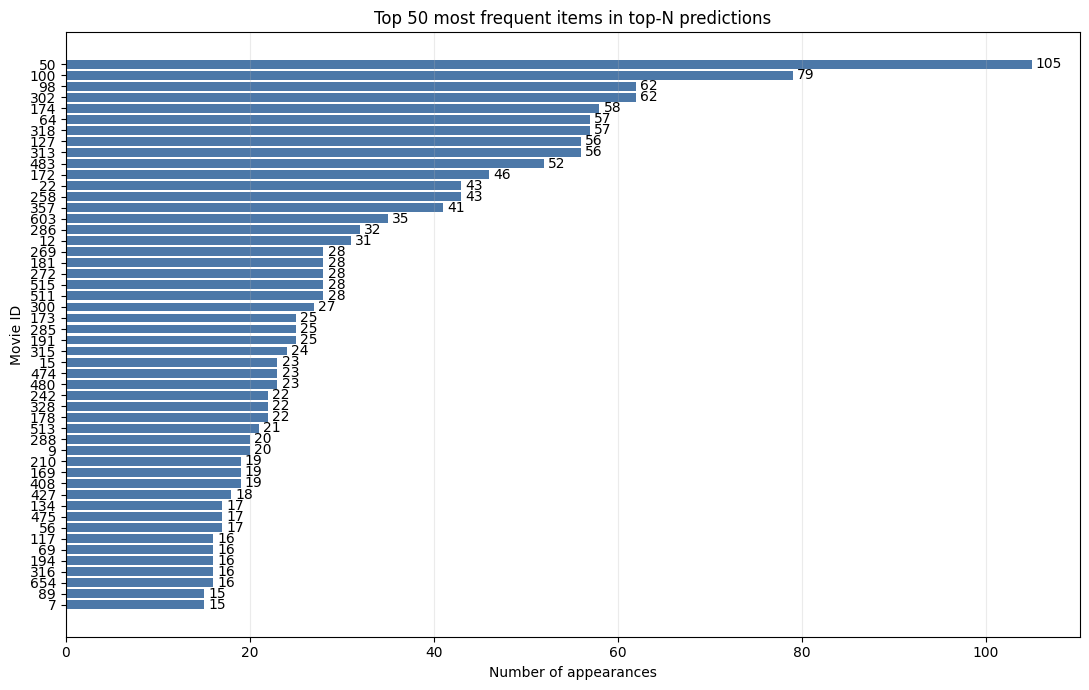

In [133]:
top_k = 50

top_freq_rcmnd = (
    freq_rcmnd.head(top_k)
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_freq_rcmnd.index.astype(str),
    top_freq_rcmnd.values,
    color="#4C78A8",
)

plt.bar_label(bars, padding=3)
plt.title("Top 50 most frequent items in top-N predictions")
plt.xlabel("Number of appearances")
plt.ylabel("Movie ID")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Correct validation

![Time series validation split](https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_013.png)


In [ ]:
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
from surprise import Dataset, Reader

In [ ]:
def build_trainset(ratings):
    data = Dataset.load_from_df(
        ratings[["userId", "movieId", "rating"]],
        Reader(rating_scale=(1, 5)),
    )
    return data.build_full_trainset()


def make_testset(ratings):
    return list(
        zip(ratings["userId"], ratings["movieId"], ratings["rating"])
    )


def time_cross_validation(params, df, cv=3):
    df = df.sort_values("timestamp").reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=cv)

    columns = ["Fold " + str(i + 1) for i in range(cv)]
    results = pd.DataFrame(index=["RMSE", "MAE"], columns=columns, dtype=float)

    fold = 0
    for train_index, test_index in tscv.split(df):
        fold += 1

        df_train_split, df_test_split = df.iloc[train_index], df.iloc[test_index]
        train_split = build_trainset(df_train_split)
        test_split = make_testset(df_test_split)

        algo = SVD(**params, random_state=42)
        algo.fit(train_split)
        predictions = algo.test(test_split)
        results.loc["RMSE", "Fold " + str(fold)] = accuracy.rmse(predictions, verbose=False)
        results.loc["MAE", "Fold " + str(fold)] = accuracy.mae(predictions, verbose=False)

    results["Mean"] = results[columns].mean(axis=1)
    results["Std"] = results[columns].std(axis=1)

    return results


def time_grid_search(param_grid, df, cv=3):
    rows = []
    for params in ParameterGrid(param_grid):
        scores = time_cross_validation(params, df, cv=cv)
        rows.append({**params, "RMSE": scores.loc["RMSE", "Mean"], "MAE": scores.loc["MAE", "Mean"]})

    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)

In [ ]:
# Random-CV score for the model whose parameters were selected above.
algo = SVD(**best_svd_params, random_state=42)
cross_validate(algo, data, measures=["RMSE", "MAE"], cv=5, verbose=True)

# Keep the latest 20% of interactions as an untouched future test set.
df_time = df.sort_values("timestamp").reset_index(drop=True)
split_index = int(len(df_time) * 0.8)
time_tuning_df = df_time.iloc[:split_index]
time_test_df = df_time.iloc[split_index:]

time_params = {
    "n_epochs": [20, 50],
    "lr_all": [0.005, 0.01],
    "reg_all": [0.02, 0.05],
}
time_search_results = time_grid_search(time_params, time_tuning_df, cv=3)
time_search_results.head()

In [ ]:
time_best_svd_params = time_search_results.iloc[0][list(time_params)].to_dict()
final_svd = SVD(**time_best_svd_params, random_state=42)
final_svd.fit(build_trainset(time_tuning_df))
final_predictions = final_svd.test(make_testset(time_test_df))

print("Selected temporal parameters:", time_best_svd_params)
print("Temporal test RMSE:", accuracy.rmse(final_predictions, verbose=False))
print("Temporal test MAE: ", accuracy.mae(final_predictions, verbose=False))